In [1]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.util import add_cyclic_point
import pandas as pd

In [2]:
data_out=np.load('fig1.npy')#5x180x360x21(20models,obs) 读取历史实验平均
olat=np.arange(-89.5,90,1)
olon=np.arange(0.5,360,1)

In [3]:
models=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','OBS']
data_out_xr=xr.DataArray(data_out,coords=[np.arange(0,5,1),olat,olon,models],dims=['vars','lat','lon','models'])

In [4]:
data_out2=np.load('fig4_s2_v2.npy')#5x180x360x21  VI指数
olat=np.arange(-89.5,90,1)
olon=np.arange(0.5,360,1)
models=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','AMME']
data_out_xr2=xr.DataArray(data_out2,coords=[np.arange(0,5,1),olat,olon,models],dims=['vars','lat','lon','models'])

In [6]:
# toa_crf_bmme=['MPI-ESM1-2-HR','CESM2-WACCM','CMCC-CM2-SR5','ACCESS-CM2']
# clt_bmme=['MPI-ESM1-2-HR','CESM2-WACCM','CMCC-CM2-SR5','ACCESS-CM2']
# sfc_crf_bmme=['MPI-ESM1-2-HR','CESM2-WACCM','CMCC-CM2-SR5','ACCESS-CM2']
# toa_crf_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']
# clt_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']
# sfc_crf_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']

In [11]:
toa_crf_bmme=['MPI-ESM1-2-HR','MPI-ESM1-2-LR','CESM2-WACCM','CMCC-CM2-SR5']
clt_bmme=['MPI-ESM1-2-HR','MPI-ESM1-2-LR','CESM2-WACCM','CMCC-CM2-SR5']
sfc_crf_bmme=['MPI-ESM1-2-HR','MPI-ESM1-2-LR','CESM2-WACCM','CMCC-CM2-SR5']
toa_crf_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']
clt_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']
sfc_crf_wmme=['FGOALS-g3','CAS-ESM2-0','NESM3','INM-CM4-8']

In [7]:
# toa_crf_bmme=['ACCESS-CM2','CESM2-WACCM','KACE-1-0-G','MIROC6','MRI-ESM2-0','CESM2-WACCM']
# clt_bmme=['MIROC6','MPI-ESM1-2-LR','MPI-ESM1-2-HR']
# sfc_crf_bmme=['ACCESS-CM2','MPI-ESM1-2-HR','KACE-1-0-G','MPI-ESM1-2-HR','GFDL-ESM4','ACCESS-ESM1-5']

# toa_crf_wmme=['NESM3','FGOALS-g3','MRI-ESM2-0','CAS-ESM2-0','NESM3','KIOST-ESM']
# clt_wmme=['FGOALS-g3','CAS-ESM2-0','CESM2-WACCM']
# sfc_crf_wmme=['KIOST-ESM','CAS-ESM2-0','NESM3','IPSL-CM6A-LR','FGOALS-g3','NESM3']

In [12]:
def draw(fig,axe,num,label,clev,data):
    pdata, plon = add_cyclic_point(data, coord=olon)
    # pdata[:,256]=data[:,254]
    # pdata[:,255]=data[:,254]
    # pdata[:,0]=data[:,1]
    if num==5 or num==6:
        c=axe.contourf(plon,olat,pdata,clev,transform=ccrs.PlateCarree(),cmap='BrBG', extend='both')
    else:
        c=axe.contourf(plon,olat,pdata,clev,transform=ccrs.PlateCarree(),cmap='bwr', extend='both')
    axe.coastlines(resolution='110m', linewidth=0.75)
    if num==1 or num==3 or num==5:
        axe.set_yticks([-60,-30,0,30,60])
        axe.set_yticklabels(['60$^\circ$S','30$^\circ$S','0','30$^\circ$N','60$^\circ$N'],fontsize=18)
    else:
        axe.set_yticks([])
    if num==5 or num==6 or num==9:
        axe.set_xticks([-90,0,90])
        axe.set_xticklabels(['90$^\circ$E','0','90$^\circ$W'],fontsize=18)
    else:
        axe.set_xticks([])
    axe.set_title(label,loc='left',fontsize=24)
    return c

In [13]:
t1=data_out_xr.loc[0,:,:,list(set(toa_crf_bmme))].mean('models')+data_out_xr.loc[1,:,:,list(set(toa_crf_bmme))].mean('models')-(data_out_xr.loc[0,:,:,'OBS']+data_out_xr.loc[1,:,:,'OBS'])
t2=data_out_xr.loc[0,:,:,list(set(toa_crf_wmme))].mean('models')+data_out_xr.loc[1,:,:,list(set(toa_crf_wmme))].mean('models')-(data_out_xr.loc[0,:,:,'OBS']+data_out_xr.loc[1,:,:,'OBS'])
t3=data_out_xr.loc[2,:,:,list(set(sfc_crf_bmme))].mean('models')+data_out_xr.loc[3,:,:,list(set(sfc_crf_bmme))].mean('models')-(data_out_xr.loc[3,:,:,'OBS']+data_out_xr.loc[2,:,:,'OBS'])
t4=data_out_xr.loc[2,:,:,list(set(sfc_crf_wmme))].mean('models')+data_out_xr.loc[3,:,:,list(set(sfc_crf_wmme))].mean('models')-(data_out_xr.loc[3,:,:,'OBS']+data_out_xr.loc[2,:,:,'OBS'])
t5=data_out_xr.loc[4,:,:,clt_bmme].mean('models')-data_out_xr.loc[4,:,:,'OBS']
t6=data_out_xr.loc[4,:,:,clt_wmme].mean('models')-data_out_xr.loc[4,:,:,'OBS']

In [14]:
tt1=data_out_xr2.loc[0,:,:,list(set(toa_crf_bmme))].mean('models')+data_out_xr2.loc[1,:,:,list(set(toa_crf_bmme))].mean('models')
tt2=data_out_xr2.loc[0,:,:,list(set(toa_crf_wmme))].mean('models')+data_out_xr2.loc[1,:,:,list(set(toa_crf_wmme))].mean('models')
tt3=data_out_xr2.loc[2,:,:,list(set(sfc_crf_bmme))].mean('models')+data_out_xr2.loc[3,:,:,list(set(sfc_crf_bmme))].mean('models')
tt4=data_out_xr2.loc[2,:,:,list(set(sfc_crf_wmme))].mean('models')+data_out_xr2.loc[3,:,:,list(set(sfc_crf_wmme))].mean('models')
tt5=data_out_xr2.loc[4,:,:,clt_bmme].mean('models')
tt6=data_out_xr2.loc[4,:,:,clt_wmme].mean('models')

In [15]:
def draw_s(fig,axe,num,label,clev,data):
    pdata, plon = add_cyclic_point(data, coord=olon)
    # pdata[:,256]=data[:,254]
    # pdata[:,255]=data[:,254]
    # pdata[:,0]=data[:,1]
    c=axe.contourf(plon,olat,pdata,clev,transform=ccrs.PlateCarree(),cmap='Reds', extend='both')
    c=axe.contourf(plon,olat,pdata,clev,transform=ccrs.PlateCarree(),cmap='Reds', extend='both')
    axe.coastlines(resolution='110m', linewidth=0.75)
    if num==1 or num==3 or num==5:
        axe.set_yticks([-60,-30,0,30,60])
        axe.set_yticklabels(['60$^\circ$S','30$^\circ$S','0','30$^\circ$N','60$^\circ$N'],fontsize=18)
    else:
        axe.set_yticks([])
    if num==5 or num==6 or num==9:
        axe.set_xticks([-90,0,90])
        axe.set_xticklabels(['90$^\circ$E','0','90$^\circ$W'],fontsize=18)
    else:
        axe.set_xticks([])
    axe.set_title(label,loc='left',fontsize=24)
    return c

In [ ]:
fig,axes=plt.subplots(3,2,subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.subplots_adjust(wspace=0.05,hspace=0.17,right=0.9,top=0.8,bottom=0.1)
fig.set_figheight(11)
fig.set_figwidth(13)
fig.set_dpi(300)
clev=np.arange(0,20,1)
c1=draw_s(fig,axes[0][0],1,'(a) Toa net crf SVI,BMME ',clev,tt1)
c2=draw_s(fig,axes[0][1],2,'(b) Toa net crf SVI,WMME',clev,tt2)
c3=draw_s(fig,axes[1][0],3,'(c) Atm net crf SVI,BMME ',clev,tt3)
c4=draw_s(fig,axes[1][1],4,'(d) Atm net crf SVI,WMME ',clev,tt4)
# clev=np.arange(0,41,5)
c5=draw_s(fig,axes[2][0],5,'(e) CLT SVI,BMME ',clev,tt5)
c6=draw_s(fig,axes[2][1],6,'(f) CLT SVI,WMME',clev,tt6)
position = fig.add_axes([0.92, 0.1, 0.010, 0.75])#位置[左,下,宽,高]
cb=fig.colorbar(c2,shrink=0.8,cax=position,fraction=0.03, format='% 1.0f')
cb.ax.tick_params(labelsize=18)
# position = fig.add_axes([0.92, 0.1, 0.010, 0.2])#位置[左,下,宽,高]
# cb=fig.colorbar(c6,cax=position,shrink=0.8,fraction=0.03, format='% 1.0f')
plt.savefig('fig5_ss.png',bbox_inches='tight')

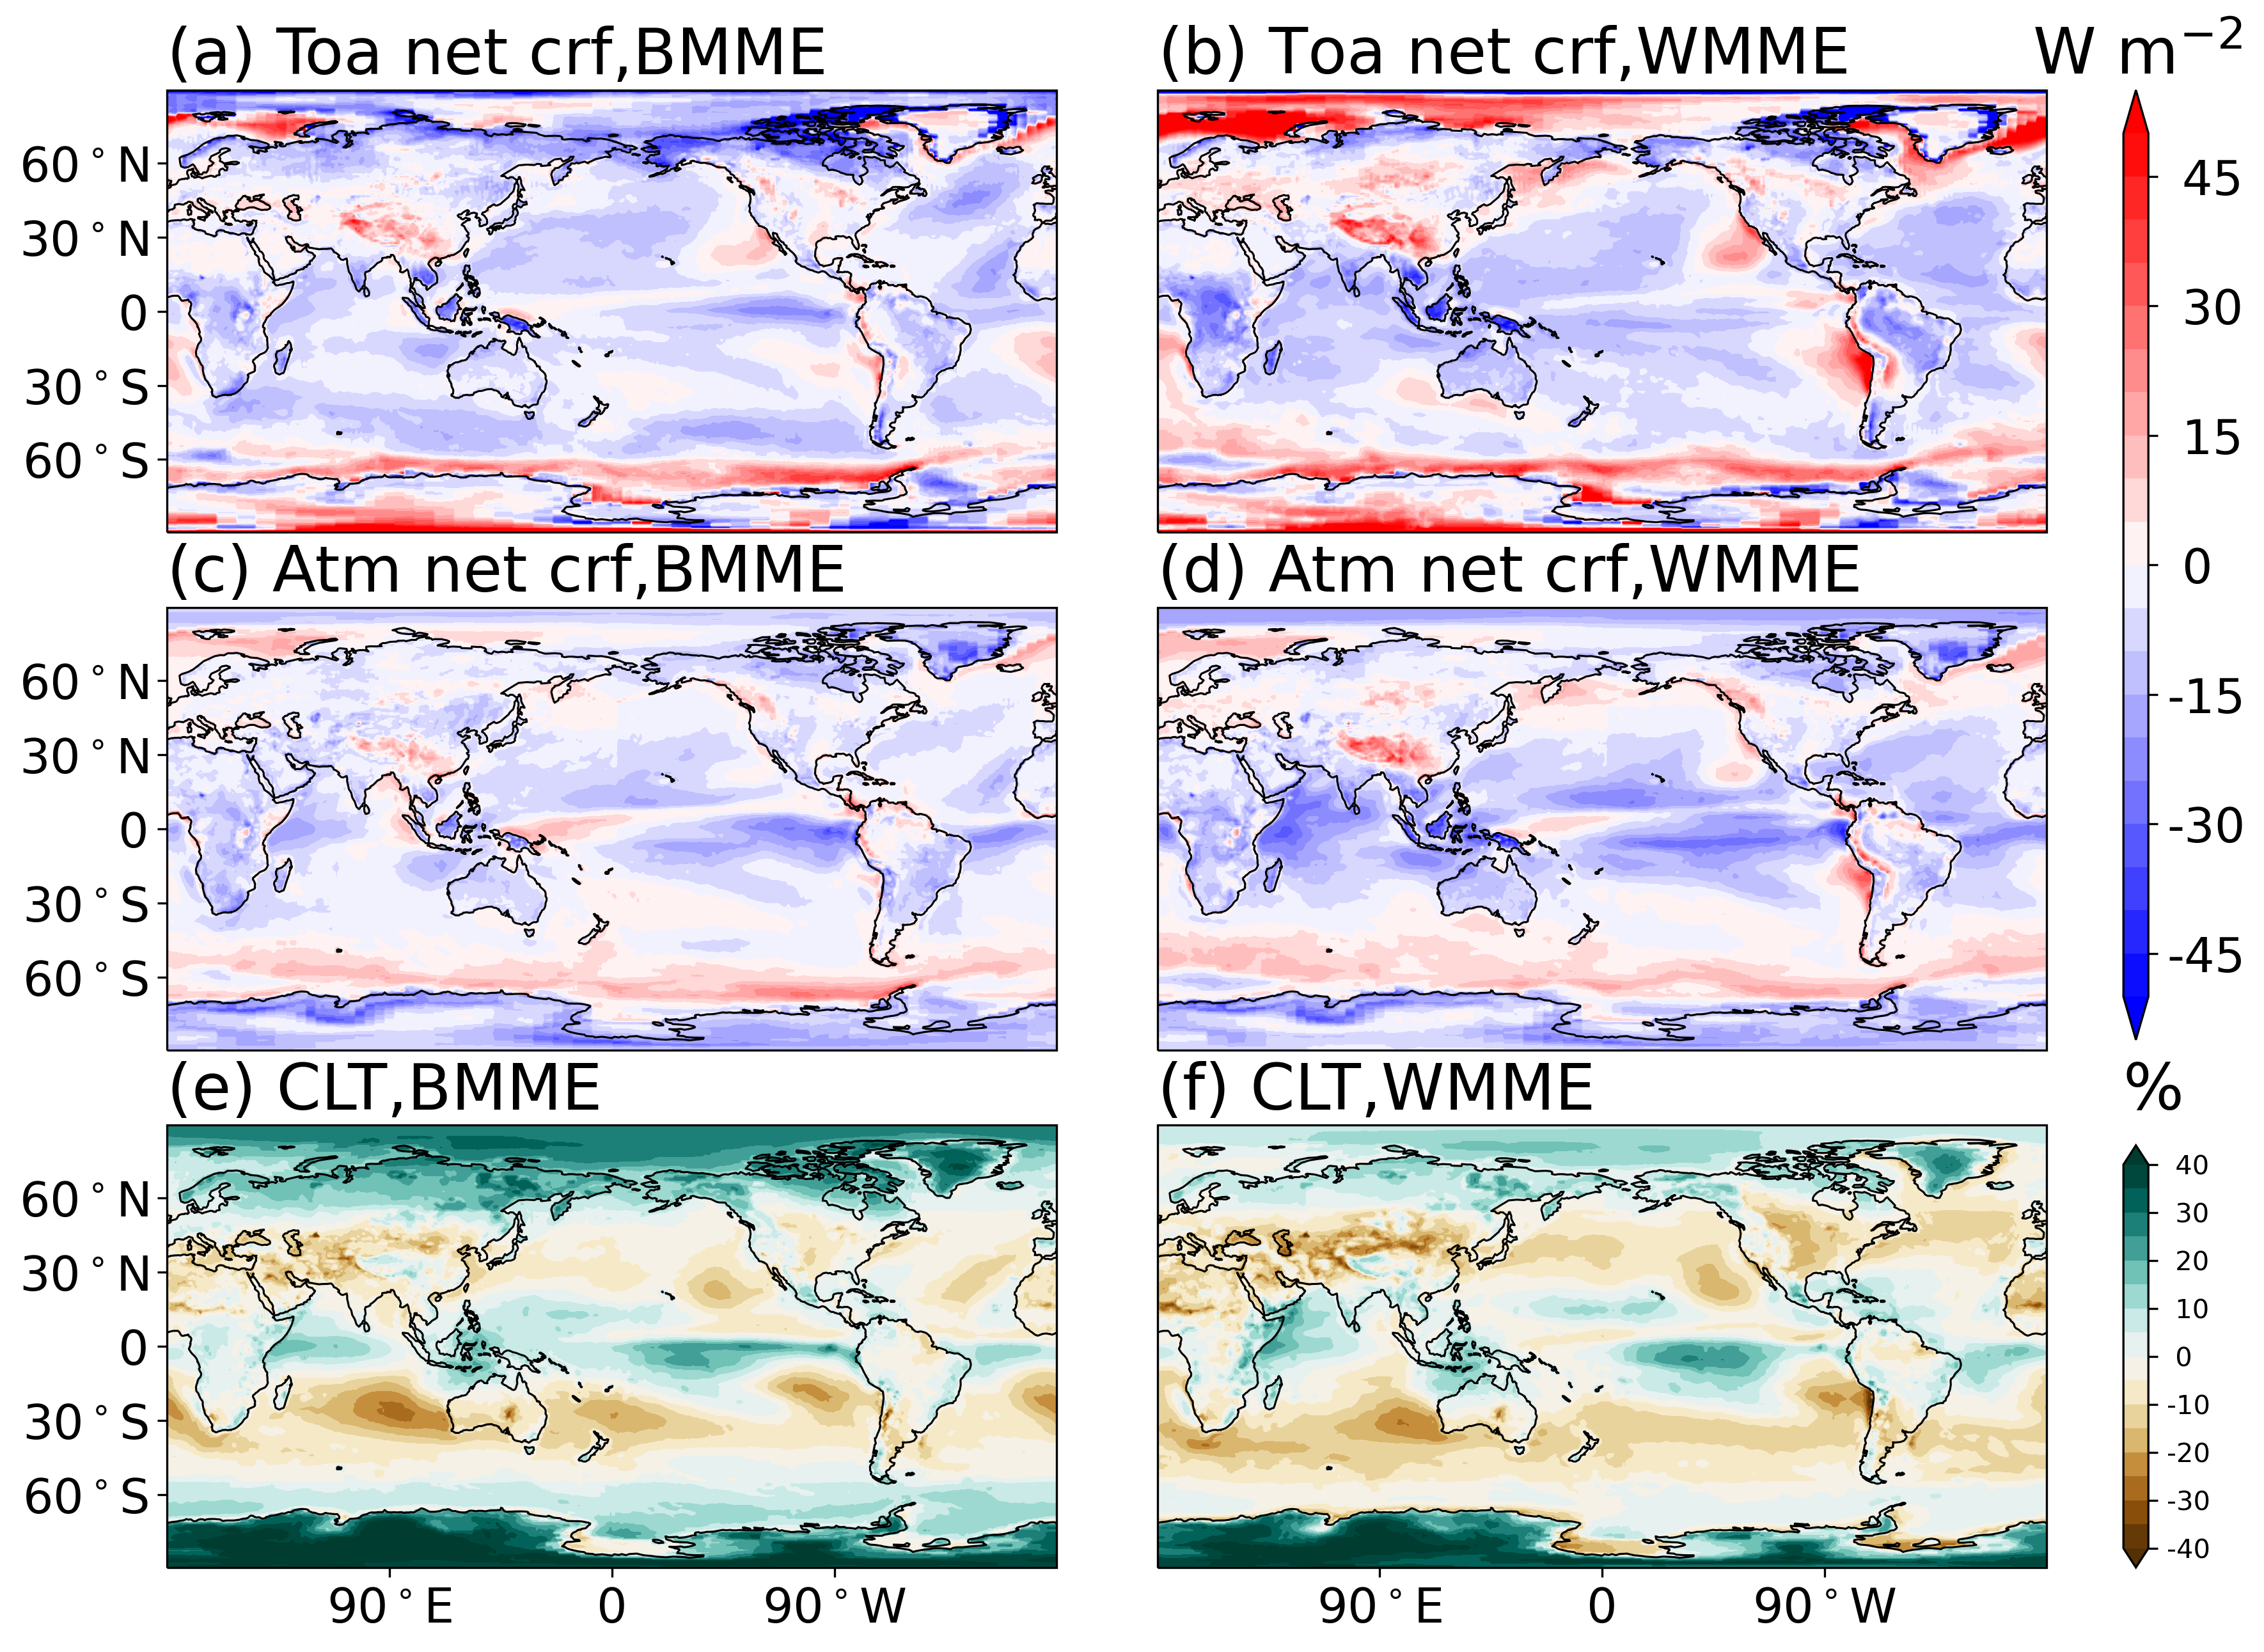

In [13]:
fig,axes=plt.subplots(3,2,subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.subplots_adjust(wspace=0.05,hspace=0.17,right=0.9,top=0.8,bottom=0.1)
fig.set_figheight(11)
fig.set_figwidth(13)
fig.set_dpi(300)
clev=np.arange(-50,51,5)
c1=draw(fig,axes[0][0],1,'(a) Toa net crf,BMME ',clev,t1)
c2=draw(fig,axes[0][1],2,'(b) Toa net crf,WMME         W m$^{-2}$',clev,t2)
c3=draw(fig,axes[1][0],3,'(c) Atm net crf,BMME ',clev,t3)
c4=draw(fig,axes[1][1],4,'(d) Atm net crf,WMME ',clev,t4)
clev=np.arange(-40,41,5)
c5=draw(fig,axes[2][0],5,'(e) CLT,BMME ',clev,t5)
c6=draw(fig,axes[2][1],6,'(f) CLT,WMME                          %',clev,t6)
position = fig.add_axes([0.92, 0.35, 0.010, 0.45])#位置[左,下,宽,高]
cb=fig.colorbar(c2,shrink=0.8,cax=position,fraction=0.03, format='% 1.0f')
cb.ax.tick_params(labelsize=18)
position = fig.add_axes([0.92, 0.1, 0.010, 0.2])#位置[左,下,宽,高]
cb=fig.colorbar(c6,cax=position,shrink=0.8,fraction=0.03, format='% 1.0f')
plt.savefig('fig5_s.png',bbox_inches='tight')

In [14]:
##读取ceres的200101-201412数据
obs=np.zeros([6,14])
ceres_path='/data04/shiy/observation/CERES_EBAF_Edition4.1_200003-202011.nc'
fc=xr.open_dataset(ceres_path)
sw_crf=fc['toa_cre_sw_mon'].loc['2001-01-01':'2014-12-30',-90:90,0:360]#time,lat,lon
weights=np.cos(np.deg2rad(sw_crf.coords['lat']))
obs[0,:]=sw_crf.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
lw_crf=fc['toa_cre_lw_mon'].loc['2001-01-01':'2014-12-30',-90:90,0:360]#time,lat,lon
weights=np.cos(np.deg2rad(lw_crf.coords['lat']))
obs[1,:]=lw_crf.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
sfc_sw_crf=fc['sfc_cre_net_sw_mon'].loc['2001-01-01':'2014-12-30',-90:90,0:360]#time,lat,lon
obs[2,:]=sfc_sw_crf.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
sfc_lw_crf=fc['sfc_cre_net_lw_mon'].loc['2001-01-01':'2014-12-30',-90:90,0:360]#time,lat,lon
obs[3,:]=sfc_lw_crf.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
#读取ISCCP-h
isccp_path='/data04/shiy/observation/isccph/isccp-basic.HGM.200101-201412.nc'
clt=xr.open_dataset(isccp_path)['cldamt'].loc['2001-01-01':'2014-12-30',-90:90,0:360]
obs[4,:]=clt.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
tas_path='/data04/shiy/observation/air.2m.mon.mean.nc'
tas=xr.open_dataset(tas_path)['air'].loc['2001-01-01':'2014-12-30',:,:]
weights=np.cos(np.deg2rad(tas.coords['lat']))
obs[5,:]=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean().values
obs2=np.zeros([6,14])
for i in range(14):
    obs2[:,i]=obs[:,i]-np.mean(obs,1)

In [15]:
data_out1=np.load('fig7_1.npy')[:,:,:]#6areax5varx1980timex24models历史实验
data_out2=np.load('fig7_2.npy')[:,:,:]#ssp245实验
data_out3=np.load('fig7_3.npy')[:,:,:]#6areax5varx1020timex24models
ssp245_ts=np.concatenate((data_out1,data_out2),axis = 1)
ssp585_ts=np.concatenate((data_out1,data_out3),axis = 1)
time=pd.date_range('18500101','20991231',freq='M')
models23=['ACCESS-CM2','ACCESS-ESM1-5','AWI-CM-1-1-MR','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CIESM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-f3-L','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']
ssp245_ts_xr=xr.DataArray(ssp245_ts,coords=[np.arange(0,6,1),time,models23],dims=['vars','time','models'])
ssp585_ts_xr=xr.DataArray(ssp585_ts,coords=[np.arange(0,6,1),time,models23],dims=['vars','time','models'])

In [16]:
llc_ssp245_ts=xr.open_dataarray('./ssp245_2015-2100_yearly_13model.nc')
llc_ssp585_ts=xr.open_dataarray('./ssp585_2015-2100_yearly_13model.nc')
models13=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CAS-ESM2-0','CMCC-CM2-SR5','CanESM5','FGOALS-g3','GFDL-ESM4','IPSL-CM6A-LR','KACE-1-0-G','MPI-ESM1-2-HR','MPI-ESM1-2-LR','NESM3']

In [17]:
llc_ssp245_ts=(llc_ssp245_ts-llc_ssp245_ts[0,:]).loc['2014':'2101']
llc_ssp585_ts=(llc_ssp585_ts-llc_ssp585_ts[0,:]).loc['2014':'2101']

In [18]:
models20=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']

In [19]:
def draw3(ax,ssp245_all,ssp245_bmme,ssp245_wmme,ssp585_all,ssp585_bmme,ssp585_wmme,obsp,label,num):
    x=np.arange(2001,2100,1)
    x1=np.arange(2001,2015,1)
    x2=np.arange(2014,2100,1)
    ax.set_xlim(2001,2100)
    ax.plot(x2,np.mean(ssp245_all,1)[13:99],'k--',label='ssp245 AMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp245_all,1)[13:99],np.max(ssp245_all,1)[13:99],alpha=0.2,color='g',label='ssp245 range')
    ax.plot(x2,ssp245_bmme.mean('models')[13:99],'r--',label='ssp245 BMME',linewidth=1.5)
    ax.plot(x2,ssp245_wmme.mean('models')[13:99],'b--',label='ssp245 WMME',linewidth=1.5)
    ax.plot(x,[0]*99,color='gray',linestyle='--')
    ax.plot(x2,np.mean(ssp585_all,1)[13:99],color='k',linestyle='dotted',label='ssp585 AMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp585_all,1)[13:99],np.max(ssp585_all,1)[13:99],alpha=0.2,color='y',label='ssp585 range')
    ax.plot(x2,ssp585_bmme.mean('models')[13:99],'r-',label='ssp585 BMME',linewidth=1.5)
    ax.plot(x2,ssp585_wmme.mean('models')[13:99],'b-',label='ssp585 WMME',linewidth=1.5)
    ax.plot(x1,np.mean(ssp245_all,1)[0:14],'k-',label='historical AMME',linewidth=1.5)
    ax.fill_between(x1,np.min(ssp245_all,1)[0:14],np.max(ssp245_all,1)[0:14],alpha=0.2,color='k')
    ax.plot(x1,ssp245_bmme.mean('models')[0:14],'r-',label='historical BMME',linewidth=1.5)
    ax.plot(x1,ssp245_wmme.mean('models')[0:14],'b-',label='historical WMME',linewidth=1.5)
    ax.plot(x1,obsp,'k--',label='OBS',linewidth=1.5)
    ax.set_title(label,loc='left',fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_xticks(np.arange(2001,2100,20))
    ax.legend(fontsize=10,bbox_to_anchor=(1,1))

In [20]:
def draw_llc(ax,ssp245_all,ssp245_bmme,ssp245_wmme,ssp585_all,ssp585_bmme,ssp585_wmme,label,num):
    x=np.arange(2001,2100,1)
    x1=np.arange(2001,2015,1)
    x2=np.arange(2015,2100,1)
    ax.set_xlim(2015,2100)
    ax.plot(x2,np.mean(ssp245_all,1),'k--',label='ssp245 AMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp245_all,1),np.max(ssp245_all,1),alpha=0.2,color='g',label='ssp245 range')
    ax.plot(x2,ssp245_bmme.mean('models'),'r--',label='ssp245 BMME',linewidth=1.5)
    ax.plot(x2,ssp245_wmme.mean('models'),'b--',label='ssp245 WMME',linewidth=1.5)
    ax.plot(x,[0]*99,color='gray',linestyle='--')
    ax.plot(x2,np.mean(ssp585_all,1),'k',label='ssp585 AMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp585_all,1),np.max(ssp585_all,1),alpha=0.2,color='y',label='ssp585 range')
    ax.plot(x2,ssp585_bmme.mean('models'),'r-',label='ssp585 BMME',linewidth=1.5)
    ax.plot(x2,ssp585_wmme.mean('models'),'b-',label='ssp585 WMME',linewidth=1.5)
    ax.set_title(label,loc='left',fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_xticks(np.arange(2015,2100,20))
    ax.legend(fontsize=10,bbox_to_anchor=(1,1))

In [34]:
# def draw3_range(ax,ssp245_all,ssp245_bmme,ssp245_wmme,ssp585_all,ssp585_bmme,ssp585_wmme,obsp,label,num):
#     x=np.arange(2001,2100,1)
#     x1=np.arange(2001,2015,1)
#     x2=np.arange(2014,2100,1)
#     ax.set_xlim(2001,2100)
#     ax.plot(x2,np.mean(ssp245_all,1)[13:99],'k--',label='ssp245 AMME',linewidth=1.5)
#     ax.plot(x2,ssp245_bmme.mean('models')[13:99],'r--',label='ssp245 BMME',linewidth=1.5)
#     ax.plot(x2,ssp245_wmme.mean('models')[13:99],'b--',label='ssp245 WMME',linewidth=1.5)
#     ax.plot(x,[0]*99,color='gray',linestyle='--')
#     ax.plot(x2,np.mean(ssp585_all,1)[13:99],'k-',label='ssp585 AMME',linewidth=1.5)
#     ax.fill_between(x2,np.min(ssp585_bmme,1)[13:99],np.max(ssp585_bmme,1)[13:99],alpha=0.2,color='r',label='SSP585 BMME range')
#     ax.plot(x2,ssp585_bmme.mean('models')[13:99],'r-',label='ssp585 BMME',linewidth=1.5)
#     ax.fill_between(x2,np.min(ssp585_wmme,1)[13:99],np.max(ssp585_wmme,1)[13:99],alpha=0.2,color='b',label='SSP585 WMME range')
#     ax.plot(x2,ssp585_wmme.mean('models')[13:99],'b-',label='ssp585 WMME',linewidth=1.5)
#     ax.plot(x1,np.mean(ssp245_all,1)[0:14],'k-',label='historical AMME',linewidth=1.5)
#     ax.fill_between(x1,np.min(ssp245_all,1)[0:14],np.max(ssp245_all,1)[0:14],alpha=0.2,color='k')
#     ax.plot(x1,ssp245_bmme.mean('models')[0:14],'r-',label='historical BMME',linewidth=1.5)
#     ax.plot(x1,ssp245_wmme.mean('models')[0:14],'b-',label='historical WMME',linewidth=1.5)
#     ax.plot(x1,obsp,'k--',label='OBS',linewidth=1.5)
#     ax.set_title(label,loc='left',fontsize=14)
#     ax.tick_params(axis='x',labelsize=14)
#     ax.tick_params(axis='y',labelsize=14)
#     ax.set_xticks(np.arange(2001,2100,20))
#     if num==1:
#         ax.legend(fontsize=10,bbox_to_anchor=(1,1))

In [41]:
def draw3_range(ax,ssp245_all,ssp245_bmme,ssp245_wmme,ssp585_all,ssp585_bmme,ssp585_wmme,obsp,label,num):
    x=np.arange(2001,2100,1)
    x1=np.arange(2001,2015,1)
    x2=np.arange(2014,2100,1)
    ax.set_xlim(2001,2100)
    ax.fill_between(x2,np.min(ssp585_bmme,1)[13:99],np.max(ssp585_bmme,1)[13:99],alpha=0.2,color='r',label='SSP585 BMME range')
    ax.plot(x2,ssp585_bmme.mean('models')[13:99],'r-',label='ssp585 BMME',linewidth=1.5)
    ax.plot(x2,ssp245_bmme.mean('models')[13:99],'r--',label='ssp245 BMME',linewidth=1.5)
    ax.plot(x1,ssp245_bmme.mean('models')[0:14],'r-',label='historical BMME',linewidth=1.5,alpha=0.5)
    ax.plot(x,[0]*99,color='gray',linestyle='--')
    ax.fill_between(x2,np.min(ssp585_wmme,1)[13:99],np.max(ssp585_wmme,1)[13:99],alpha=0.2,color='b',label='SSP585 WMME range')
    ax.plot(x2,ssp585_wmme.mean('models')[13:99],'b-',label='ssp585 WMME',linewidth=1.5)
    ax.plot(x2,ssp245_wmme.mean('models')[13:99],'b--',label='ssp245 WMME',linewidth=1.5)
    ax.plot(x1,ssp245_wmme.mean('models')[0:14],'b-',label='historical WMME',linewidth=1.5,alpha=0.5)
    ax.plot(x2,np.mean(ssp585_all,1)[13:99],'k-',label='ssp585 AMME',linewidth=1.5)
    ax.plot(x2,np.mean(ssp245_all,1)[13:99],'k--',label='ssp245 AMME',linewidth=1.5)
    ax.plot(x1,np.mean(ssp245_all,1)[0:14],'k-',label='historical AMME',linewidth=1.5,alpha=0.5)
    ax.fill_between(x1,np.min(ssp245_all,1)[0:14],np.max(ssp245_all,1)[0:14],alpha=0.2,color='k')
    ax.plot(x1,obsp,'y--',label='OBS',linewidth=1.5)
    ax.set_title(label,loc='left',fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_xticks(np.arange(2001,2100,20))
    if num==1:
        ax.legend(fontsize=10,bbox_to_anchor=(1,1))

In [22]:
def draw_llc_range(ax,ssp245_all,ssp245_bmme,ssp245_wmme,ssp585_all,ssp585_bmme,ssp585_wmme,label):
    x=np.arange(2001,2100,1)
    x1=np.arange(2001,2015,1)
    x2=np.arange(2015,2100,1)
    ax.set_xlim(2015,2100)
    ax.plot(x2,np.mean(ssp245_all,1),'k--',label='ssp245 AMME',linewidth=1.5)
    ax.plot(x2,ssp245_bmme.mean('models'),'r--',label='ssp245 BMME',linewidth=1.5)
    ax.plot(x2,ssp245_wmme.mean('models'),'b--',label='ssp245 WMME',linewidth=1.5)
    ax.plot(x,[0]*99,color='gray',linestyle='--')
    ax.plot(x2,np.mean(ssp585_all,1),'k-',label='ssp585 AMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp585_bmme,1),np.max(ssp585_bmme,1),alpha=0.2,color='r',label='SSP585 BMME range')
    ax.plot(x2,ssp585_bmme.mean('models'),'r-',label='ssp585 BMME',linewidth=1.5)
    ax.fill_between(x2,np.min(ssp585_wmme,1),np.max(ssp585_wmme,1),alpha=0.2,color='b',label='SSP585 WMME range')
    ax.plot(x2,ssp585_wmme.mean('models'),'b-',label='ssp585 WMME',linewidth=1.5)

    ax.set_title(label,loc='left',fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_xticks(np.arange(2015,2100,20))
    ax.legend(fontsize=10,bbox_to_anchor=(1,1))

In [23]:
t1=(ssp245_ts_xr.loc[0,:,models20]+ssp245_ts_xr.loc[1,:,models20]).groupby('time.year').mean().loc['2001':'2101']
t2=(ssp585_ts_xr.loc[0,:,models20]+ssp585_ts_xr.loc[1,:,models20]).groupby('time.year').mean().loc['2001':'2101']
t3=(ssp245_ts_xr.loc[2,:,models20]+ssp245_ts_xr.loc[3,:,models20]).groupby('time.year').mean().loc['2001':'2101']
t4=(ssp585_ts_xr.loc[2,:,models20]+ssp585_ts_xr.loc[3,:,models20]).groupby('time.year').mean().loc['2001':'2101']
t5=ssp245_ts_xr.loc[4,:,models20].groupby('time.year').mean().loc['2001':'2101']
t6=ssp585_ts_xr.loc[4,:,models20].groupby('time.year').mean().loc['2001':'2101']
t7=ssp245_ts_xr.loc[5,:,models20].groupby('time.year').mean().loc['2001':'2101']
t8=ssp585_ts_xr.loc[5,:,models20].groupby('time.year').mean().loc['2001':'2101']
t1=t1-np.mean(t1[0:14,:],0)
t2=t2-np.mean(t2[0:14,:],0)
t3=t3-np.mean(t3[0:14,:],0)
t4=t4-np.mean(t4[0:14,:],0)
t5=t5-np.mean(t5[0:14,:],0)
t6=t6-np.mean(t6[0:14,:],0)
t7=t7-np.mean(t7[0:14,:],0)
t8=t8-np.mean(t8[0:14,:],0)

In [24]:
# fig,ax=plt.subplots(4,1,figsize=(12,15),dpi=300)
# colors=plt.cm.nipy_spectral(np.linspace(0,1,20))
# draw3(ax[0],t1,t1.loc[:,list(set(toa_crf_bmme))],t1.loc[:,list(set(toa_crf_wmme))],t2,t2.loc[:,list(set(toa_crf_bmme))],t2.loc[:,list(set(toa_crf_wmme))],obs2[0,:]+obs2[1,:],'a) Toa net crf',1)
# draw3(ax[1],t3,t3.loc[:,list(set(sfc_crf_bmme))],t3.loc[:,list(set(sfc_crf_wmme))],t4,t4.loc[:,list(set(sfc_crf_bmme))],t4.loc[:,list(set(sfc_crf_wmme))],obs2[2,:]+obs2[3,:],'b) sfc net crf',2)
# draw3(ax[2],t5,t5.loc[:,clt_bmme],t5.loc[:,clt_wmme],t6,t6.loc[:,clt_bmme],t6.loc[:,clt_wmme],obs2[4,:],'c) CLT',3)
# draw_llc(ax[3],llc_ssp245_ts,llc_ssp245_ts.loc[:,list(set(models13).intersection(clt_bmme))],llc_ssp245_ts.loc[:,list(set(models13).intersection(clt_wmme))],llc_ssp585_ts,llc_ssp585_ts.loc[:,list(set(models13).intersection(clt_bmme))],llc_ssp585_ts.loc[:,list(set(models13).intersection(clt_wmme))],'d) LLC',3)
# plt.savefig('fig7.png',bbox_inches='tight')

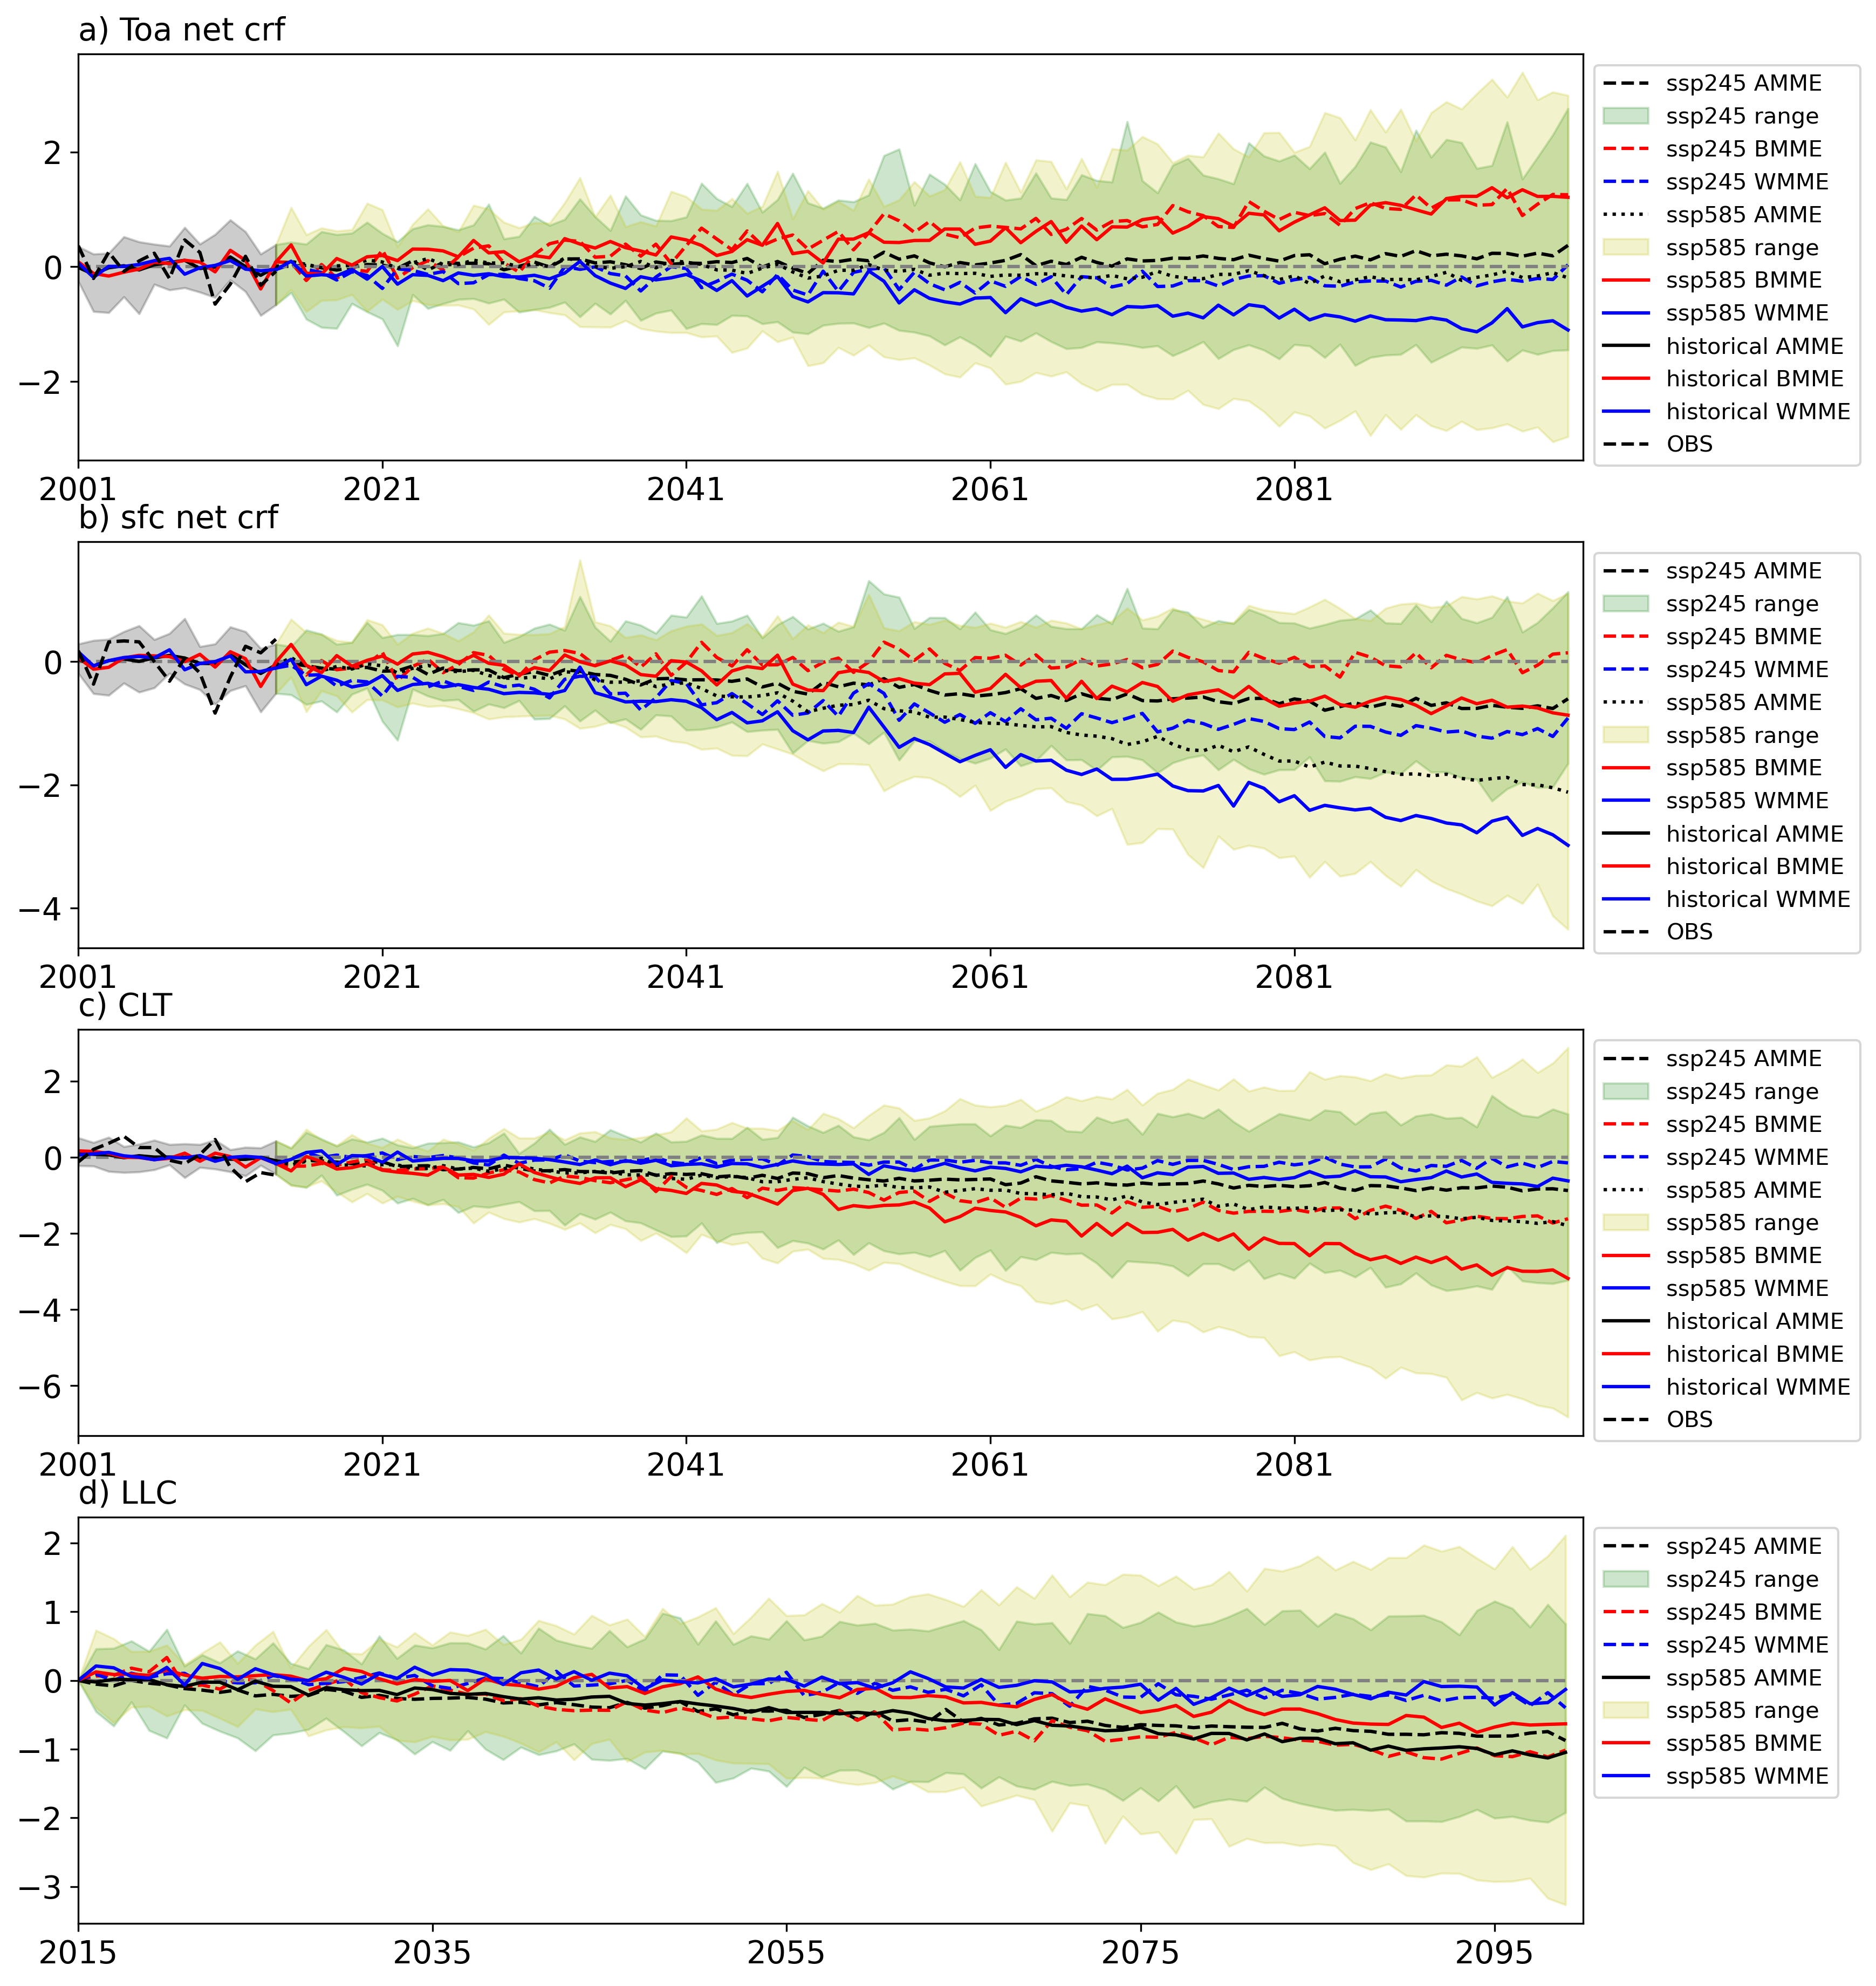

In [25]:
fig,ax=plt.subplots(4,1,figsize=(12,15),dpi=300)
colors=plt.cm.nipy_spectral(np.linspace(0,1,20))
draw3(ax[0],t1,t1.loc[:,list(set(toa_crf_bmme))],t1.loc[:,list(set(toa_crf_wmme))],t2,t2.loc[:,list(set(toa_crf_bmme))],t2.loc[:,list(set(toa_crf_wmme))],obs2[0,:]+obs2[1,:],'a) Toa net crf',1)
draw3(ax[1],t3,t3.loc[:,list(set(sfc_crf_bmme))],t3.loc[:,list(set(sfc_crf_wmme))],t4,t4.loc[:,list(set(sfc_crf_bmme))],t4.loc[:,list(set(sfc_crf_wmme))],obs2[2,:]+obs2[3,:],'b) sfc net crf',2)
draw3(ax[2],t5,t5.loc[:,list(set(toa_crf_bmme))],t5.loc[:,list(set(toa_crf_wmme))],t6,t6.loc[:,list(set(toa_crf_bmme))],t6.loc[:,list(set(toa_crf_wmme))],obs2[4,:],'c) CLT',3)
draw_llc(ax[3],llc_ssp245_ts,llc_ssp245_ts.loc[:,list(set(models13).intersection(toa_crf_bmme))],llc_ssp245_ts.loc[:,list(set(models13).intersection(toa_crf_wmme))],llc_ssp585_ts,llc_ssp585_ts.loc[:,list(set(models13).intersection(toa_crf_bmme))],llc_ssp585_ts.loc[:,list(set(models13).intersection(toa_crf_wmme))],'d) LLC',3)
plt.savefig('fig7_all.png',bbox_inches='tight')

In [26]:
list(set(models13).intersection(toa_crf_bmme))

['ACCESS-CM2', 'MPI-ESM1-2-HR', 'CMCC-CM2-SR5']

In [27]:
models13

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'BCC-CSM2-MR',
 'CAS-ESM2-0',
 'CMCC-CM2-SR5',
 'CanESM5',
 'FGOALS-g3',
 'GFDL-ESM4',
 'IPSL-CM6A-LR',
 'KACE-1-0-G',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NESM3']

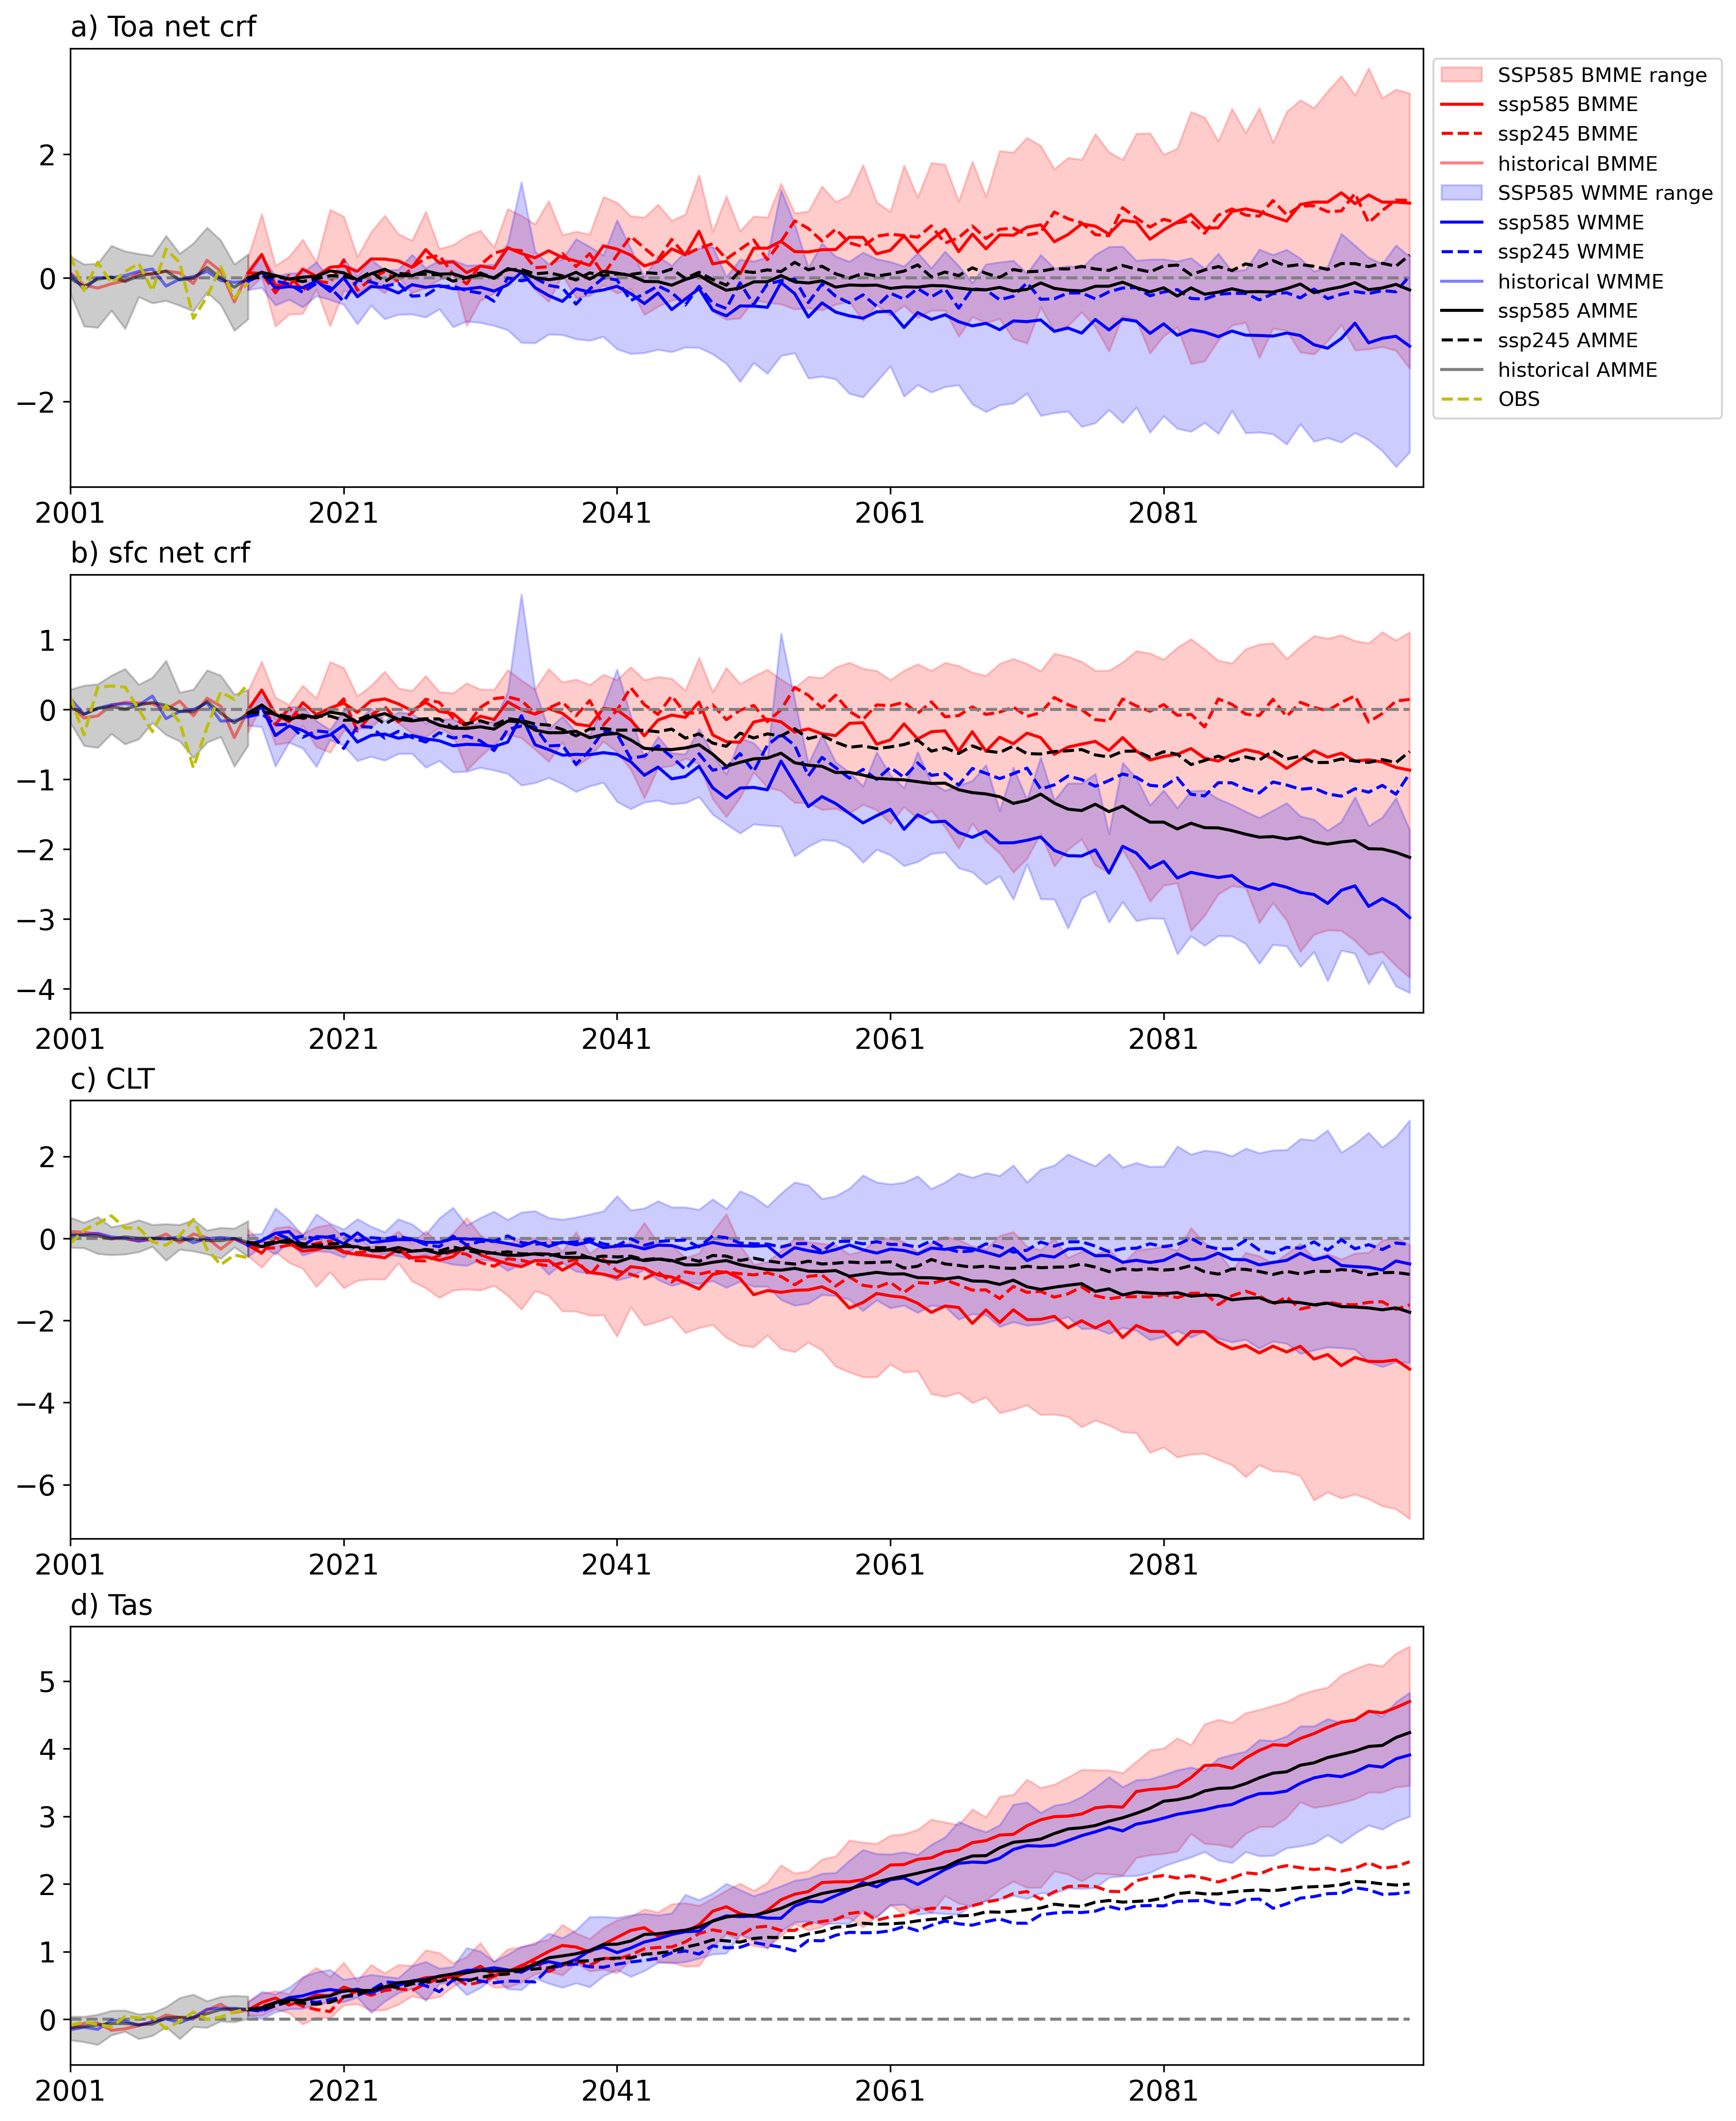

In [42]:
fig,ax=plt.subplots(4,1,figsize=(12,18),dpi=300)
colors=plt.cm.nipy_spectral(np.linspace(0,1,20))
draw3_range(ax[0],t1,t1.loc[:,list(set(toa_crf_bmme))],t1.loc[:,list(set(toa_crf_wmme))],t2,t2.loc[:,list(set(toa_crf_bmme))],t2.loc[:,list(set(toa_crf_wmme))],obs2[0,:]+obs2[1,:],'a) Toa net crf',1)
draw3_range(ax[1],t3,t3.loc[:,list(set(sfc_crf_bmme))],t3.loc[:,list(set(sfc_crf_wmme))],t4,t4.loc[:,list(set(sfc_crf_bmme))],t4.loc[:,list(set(sfc_crf_wmme))],obs2[2,:]+obs2[3,:],'b) sfc net crf',2)
draw3_range(ax[2],t5,t5.loc[:,list(set(toa_crf_bmme))],t5.loc[:,list(set(toa_crf_wmme))],t6,t6.loc[:,list(set(toa_crf_bmme))],t6.loc[:,list(set(toa_crf_wmme))],obs2[4,:],'c) CLT',3)
draw3_range(ax[3],t7,t7.loc[:,list(set(toa_crf_bmme))],t7.loc[:,list(set(toa_crf_wmme))],t8,t8.loc[:,list(set(toa_crf_bmme))],t8.loc[:,list(set(toa_crf_wmme))],obs2[5,:],'d) Tas',4)
# draw_llc_range(ax[4],llc_ssp245_ts,llc_ssp245_ts.loc[:,list(set(models13).intersection(toa_crf_bmme))],llc_ssp245_ts.loc[:,list(set(models13).intersection(toa_crf_wmme))],llc_ssp585_ts,llc_ssp585_ts.loc[:,list(set(models13).intersection(toa_crf_bmme))],llc_ssp585_ts.loc[:,list(set(models13).intersection(toa_crf_wmme))],'d) LLC')
plt.savefig('fig7_BW.png',bbox_inches='tight')